# Tag 1, Run 1 — Kandidatenvergleich: MyopicPlus Centrality vs. CFA-Future Centrality

**Kernfrage:** Sind die Kandidaten für den Initialplan bei beiden Modellen an Tag 1 identisch?

Beide Modelle verwenden `zone_selection_mode: centrality` → rein geometrisches Zonen-Scoring (mittlere Distanz zu anderen Zentroiden). Da Seed, n_zones und der Anfangszustand (alle Stationen bei dsm=365, kein Carryover) gleich sind, **müssen** die Kandidaten gleich sein. Die Routen-Reihenfolge unterscheidet sich jedoch, weil MyopicPlus und CFA-Future unterschiedliche Insertion-Costs verwenden.

In [1]:
import json
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

ROOT = Path('/home/philipphuemmer/workspace/masterarbeit')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print(f"Projektroot: {ROOT}")

from src.data.loader import load_stations, get_coordinates
import yaml

with open(ROOT / 'configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

df = load_stations(cfg)
all_coords = np.array(get_coordinates(df, cfg))  # shape (398, 2): Index 0 = Depot
depot_coord = all_coords[0]
print(f"Stationen: {len(df)}, Koordinaten inkl. Depot: {len(all_coords)}")
print(f"Depot: {depot_coord}")

Projektroot: /home/philipphuemmer/workspace/masterarbeit
Stationen: 397, Koordinaten inkl. Depot: 398
Depot: [49.776414  9.938582]


In [2]:
# Lädt Run 147 für beide Modelle (Tag 1: nur 2 Störungen je Modell, kein Carryover)
with open('logs/myopic_plus_centrality/json/run_147.json') as f:
    myopic = json.load(f)
with open('logs/cfa_future_centrality/json/run_147.json') as f:
    cfa = json.load(f)

# Hour 8, Day 1 = Initialplan-Eintrag
mh1 = myopic['hourly'][0]
ch1 = cfa['hourly'][0]

assert mh1['day'] == 1 and mh1['hour'] == 8
assert ch1['day'] == 1 and ch1['hour'] == 8
print("Stunde/Tag korrekt geladen: Day 1, Hour 8")

Stunde/Tag korrekt geladen: Day 1, Hour 8


In [3]:
# ── Kandidaten extrahieren ──────────────────────────────────────────────────
def get_candidates(hourly_entry):
    tasks = hourly_entry['solver_debug']['input']['tasks_per_team']
    return {int(team): [t['node_idx'] for t in task_list] for team, task_list in tasks.items()}

mc = get_candidates(mh1)
cc = get_candidates(ch1)

print("MYOPIC Kandidaten:")
for t, nodes in mc.items():
    print(f"  Team {t}: {nodes}")
print()
print("CFA-FUTURE Kandidaten:")
for t, nodes in cc.items():
    print(f"  Team {t}: {nodes}")
print()
print("Kandidaten identisch?", mc == cc)

MYOPIC Kandidaten:
  Team 0: [30, 31, 36, 37, 38, 32, 59, 201, 203, 158]
  Team 1: [45, 46, 48, 13, 23, 24, 26, 11, 12, 6]

CFA-FUTURE Kandidaten:
  Team 0: [30, 31, 36, 37, 38, 32, 59, 201, 203, 158]
  Team 1: [45, 46, 48, 13, 23, 24, 26, 11, 12, 6]

Kandidaten identisch? True


In [4]:
# ── Routen extrahieren ─────────────────────────────────────────────────────
def get_route(initial_plan, team_id):
    """Gibt Liste von Stop-Dicts zurück; überspringt Einträge ohne node_idx (z.B. Mittagspause)."""
    for entry in initial_plan:
        if entry['team_id'] == team_id:
            return [
                {
                    'node_idx': s['node_idx'],
                    'arrival': s['arrival_time'],
                    'departure': s['departure_time'],
                    'travel_km': s.get('travel_km', 0),
                    'travel_min': s.get('travel_time_min', 0),
                    'dsm': s.get('days_since_maintenance', None),
                    'task_type': s.get('task_type', 'routine'),
                }
                for s in entry['route']
                if 'node_idx' in s  # Mittagspause / interne Events ausschließen
            ]
    return []

mr0 = get_route(mh1['initial_plan'], 0)
mr1 = get_route(mh1['initial_plan'], 1)
cr0 = get_route(ch1['initial_plan'], 0)
cr1 = get_route(ch1['initial_plan'], 1)

print(f"MyopicPlus  | Team 0: {len(mr0)} Stops | Team 1: {len(mr1)} Stops")
print(f"CFA-Fut | Team 0: {len(cr0)} Stops | Team 1: {len(cr1)} Stops")
print()
print("MyopicPlus  Team 0 Route:", [s['node_idx'] for s in mr0])
print("CFA-Fut Team 0 Route:", [s['node_idx'] for s in cr0])
print()
print("MyopicPlus  Team 1 Route:", [s['node_idx'] for s in mr1])
print("CFA-Fut Team 1 Route:", [s['node_idx'] for s in cr1])

MyopicPlus  | Team 0: 10 Stops | Team 1: 10 Stops
CFA-Fut | Team 0: 10 Stops | Team 1: 9 Stops

MyopicPlus  Team 0 Route: [59, 201, 203, 32, 158, 37, 38, 30, 31, 36]
CFA-Fut Team 0 Route: [36, 30, 31, 59, 201, 203, 32, 158, 37, 38]

MyopicPlus  Team 1 Route: [13, 24, 23, 26, 11, 12, 6, 48, 45, 46]
CFA-Fut Team 1 Route: [45, 46, 48, 13, 11, 12, 26, 23, 24]


## Visualisierung 1 — Kandidaten & Routen auf der Karte (Tag 1)

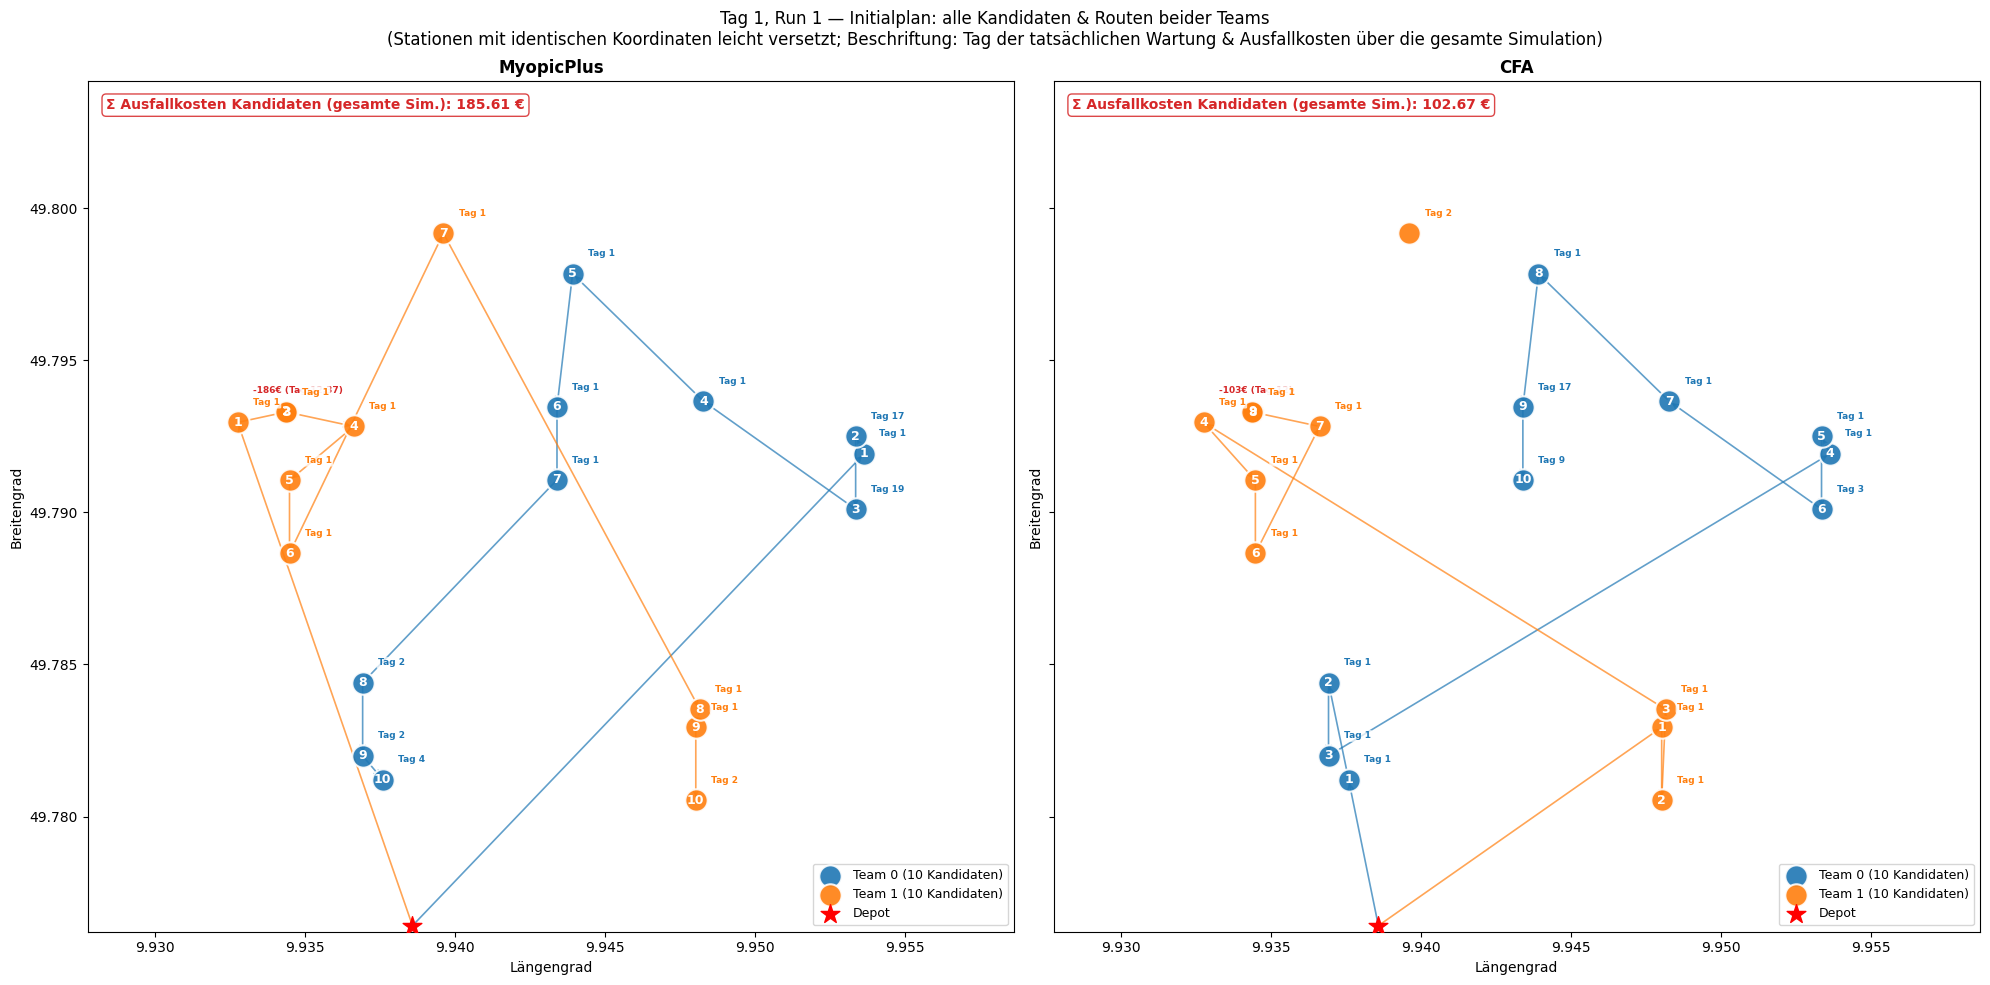

In [5]:
import re
from collections import defaultdict

TEAM_COLORS = ['#1f77b4', '#ff7f0e']  # blau = Team 0, orange = Team 1
MARGIN = 0.005

# Zoom auf alle Kandidaten beider Teams
all_cand_nodes = set(n for t in mc.values() for n in t) | set(n for t in cc.values() for n in t)
all_cand_coords = np.array([all_coords[n] for n in all_cand_nodes])
lat_min = all_cand_coords[:, 0].min() - MARGIN
lat_max = all_cand_coords[:, 0].max() + MARGIN
lon_min = all_cand_coords[:, 1].min() - MARGIN
lon_max = all_cand_coords[:, 1].max() + MARGIN

# ── Mehrere Kandidaten teilen sich exakt dieselben Koordinaten (z.B. 30/31,
# 37/38, 201/203, 45/46, 11/12, 23/24) → ohne Jitter liegen ihre Marker
# exakt übereinander. Wir verteilen sie minimal kreisförmig um den
# eigentlichen Standort, damit jede Station als eigener Punkt sichtbar ist.
JITTER_RADIUS = 0.0012

def jitter_coords(nodes, all_coords, radius=JITTER_RADIUS):
    groups = defaultdict(list)
    for n in nodes:
        key = tuple(np.round(all_coords[n], 6))
        groups[key].append(n)
    jittered = {}
    for key, group_nodes in groups.items():
        base = np.array(key)
        k = len(group_nodes)
        if k == 1:
            jittered[group_nodes[0]] = base
        else:
            for i, n in enumerate(group_nodes):
                angle = 2 * np.pi * i / k
                offset = radius * np.array([np.cos(angle), np.sin(angle)])
                jittered[n] = base + offset
    return jittered

jittered_coords = jitter_coords(all_cand_nodes, all_coords)

# ── Hilfsfunktionen: über die komplette Simulation auswerten ───────────────
_NODE_RE = re.compile(r'@ (\d+) →')
_COST_RE = re.compile(r'Ausfall ([\d.]+) EUR')

def get_all_completion_days(run_json):
    """Erster Tag, an dem jede Station tatsächlich als Routine-Aufgabe
    abgefahren wurde (completed=True im executed_plan), über die ganze Simulation."""
    days = {}
    for e in run_json['hourly']:
        if 'executed_plan' not in e:
            continue
        for team_entry in e['executed_plan']:
            for s in team_entry['route']:
                if s.get('completed') and s['node_idx'] not in days:
                    days[s['node_idx']] = e['day']
    return days

def get_all_disruption_costs(run_json):
    """Summe der Ausfallkosten je Station + Liste der Tage, an denen eine
    Störung auftrat, über die ganze Simulation (geparst aus den Hourly-Notes)."""
    costs = {}
    days_map = defaultdict(list)
    pending_node = None
    pending_day = None
    for e in run_json['hourly']:
        if 'notes' not in e:
            continue
        for note in e['notes']:
            m = _NODE_RE.search(note)
            if m:
                pending_node = int(m.group(1))
                pending_day = e['day']
            m2 = _COST_RE.search(note)
            if m2 and pending_node is not None:
                costs[pending_node] = costs.get(pending_node, 0.0) + float(m2.group(1))
                days_map[pending_node].append(pending_day)
                pending_node = None
    return costs, days_map

m_completion_days = get_all_completion_days(myopic)
c_completion_days = get_all_completion_days(cfa)
m_all_disruption_costs, m_disruption_days = get_all_disruption_costs(myopic)
c_all_disruption_costs, c_disruption_days = get_all_disruption_costs(cfa)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=True, sharey=True)

for ax, (model_name, candidates, routes, completion_days, disruption_costs, disruption_days) in zip(axes, [
    ('MyopicPlus', mc, [mr0, mr1], m_completion_days, m_all_disruption_costs, m_disruption_days),
    ('CFA', cc, [cr0, cr1], c_completion_days, c_all_disruption_costs, c_disruption_days),
]):
    cand_total_cost = 0.0
    for tid, (color, route) in enumerate(zip(TEAM_COLORS, routes)):
        cand_nodes = candidates[tid]
        cand_coords = np.array([jittered_coords[n] for n in cand_nodes])

        # Kandidaten-Punkte (jitter-Positionen)
        ax.scatter(cand_coords[:, 1], cand_coords[:, 0],
                   s=260, color=color, zorder=3, alpha=0.9,
                   edgecolor='white', linewidth=1.5,
                   label=f'Team {tid} ({len(cand_nodes)} Kandidaten)')

        # Routen-Pfeile (zwischen jitter-Positionen) — nur für Stationen,
        # die tatsächlich Teil der Tag-1-Route sind
        route_nodes = [0] + [s['node_idx'] for s in route]
        for i in range(len(route_nodes) - 1):
            n_a, n_b = route_nodes[i], route_nodes[i + 1]
            a = jittered_coords[n_a] if n_a != 0 else all_coords[0]
            b = jittered_coords[n_b] if n_b != 0 else all_coords[0]
            a_vis = lat_min <= a[0] <= lat_max and lon_min <= a[1] <= lon_max
            b_vis = lat_min <= b[0] <= lat_max and lon_min <= b[1] <= lon_max
            if a_vis or b_vis:
                ax.annotate('', xy=(b[1], b[0]), xytext=(a[1], a[0]),
                            arrowprops=dict(arrowstyle='->', color=color,
                                            lw=1.2, alpha=0.7),
                            zorder=2)

        # Reihenfolge der Route (1-basiert) je Knoten — Kandidaten, die an
        # Tag 1 nicht Teil der Route sind (z.B. direkt zu Carryover geworden,
        # wie Node 23 bei CFA Team 1), bekommen keine Schritt-Nummer im Kreis,
        # aber trotzdem ein Tag-/Kosten-Label
        route_step = {s['node_idx']: step for step, s in enumerate(route, start=1)}

        for n in cand_nodes:
            coord = jittered_coords[n]
            step = route_step.get(n)
            if step is not None:
                ax.annotate(str(step), xy=(coord[1], coord[0]),
                            fontsize=9, ha='center', va='center',
                            color='white', fontweight='bold', zorder=5)

            # Tag der tatsächlichen Wartung & Ausfallkosten (über die ganze
            # Simulation), getrennt beschriftet: "Tag X" immer in Teamfarbe,
            # Ausfallkosten inkl. Störungstag(en) in Rot
            comp_day = completion_days.get(n)
            cost = disruption_costs.get(n, 0.0)
            cand_total_cost += cost

            y_off = 11
            if comp_day is not None:
                ax.annotate(f"Tag {comp_day}", xy=(coord[1], coord[0]),
                            xytext=(11, y_off), textcoords='offset points',
                            fontsize=6.5, ha='left', va='bottom',
                            color=color, fontweight='bold', zorder=6,
                            bbox=dict(boxstyle='round,pad=0.15', fc='white',
                                      ec='none', alpha=0.75))
                y_off += 9
            if cost > 0:
                days_str = ','.join(str(d) for d in disruption_days.get(n, []))
                ax.annotate(f"-{cost:.0f}€ (Tag:{days_str})", xy=(coord[1], coord[0]),
                            xytext=(11, y_off), textcoords='offset points',
                            fontsize=6.5, ha='left', va='bottom',
                            color='#d62728', fontweight='bold', zorder=6,
                            bbox=dict(boxstyle='round,pad=0.15', fc='white',
                                      ec='none', alpha=0.75))

    # Depot
    if lat_min <= depot_coord[0] <= lat_max and lon_min <= depot_coord[1] <= lon_max:
        ax.scatter(depot_coord[1], depot_coord[0],
                   s=200, marker='*', color='red', zorder=4, label='Depot')

    # Summe der Ausfallkosten aller Kandidaten-Stationen (gesamte Simulation)
    ax.text(0.02, 0.98, f"Σ Ausfallkosten Kandidaten (gesamte Sim.): {cand_total_cost:.2f} €",
            transform=ax.transAxes, ha='left', va='top', fontsize=10,
            fontweight='bold', color='#d62728',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d62728', alpha=0.85))

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Längengrad')
    ax.set_ylabel('Breitengrad')
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle('Tag 1, Run 1 — Initialplan: alle Kandidaten & Routen beider Teams\n'
              '(Stationen mit identischen Koordinaten leicht versetzt; '
              'Beschriftung: Tag der tatsächlichen Wartung & Ausfallkosten über die gesamte Simulation)',
              fontsize=12)
plt.tight_layout()
plt.show()

## Visualisierung 1b — Tatsächliche Routen inkl. Störungen (Tag 1)

Zeigt die **tatsächlich gefahrenen Routen** inkl. eingeschobener Störungseinsätze (Dreieck-Marker). Die ursprünglich geplante Route ist gestrichelt im Hintergrund eingezeichnet — Abschnitte, die **nicht abgefahren wurden** (Carryover-Stops, leere Kreis-Marker), erscheinen nur gestrichelt.

In [6]:
# ── Tatsächliche Routen extrahieren (inkl. Störungen) ───────────────────────
def get_executed_route(run_json, day, team_id):
    """Extrahiert die tatsächlich gefahrene Route (inkl. Störungen) aus dem
    letzten Stundeneintrag (executed_plan) des angegebenen Tages."""
    for entry in run_json['hourly']:
        if entry['day'] == day and 'executed_plan' in entry:
            for team_entry in entry['executed_plan']:
                if team_entry['team_id'] == team_id:
                    return [
                        {'node_idx': s['node_idx'], 'task_type': s.get('task_type', 'routine')}
                        for s in team_entry['route']
                    ]
    return []

mer0 = get_executed_route(myopic, 1, 0)
mer1 = get_executed_route(myopic, 1, 1)
cer0 = get_executed_route(cfa, 1, 0)
cer1 = get_executed_route(cfa, 1, 1)

print("MyopicPlus  Team 0 tatsächlich:", [s['node_idx'] for s in mer0])
print("CFA-Fut Team 0 tatsächlich:", [s['node_idx'] for s in cer0])
print()
print("MyopicPlus  Team 1 tatsächlich:", [s['node_idx'] for s in mer1])
print("CFA-Fut Team 1 tatsächlich:", [s['node_idx'] for s in cer1])


MyopicPlus  Team 0 tatsächlich: [332, 59, 367, 32, 158, 37, 38]
CFA-Fut Team 0 tatsächlich: [36, 30, 31, 367, 59, 201, 32, 158]

MyopicPlus  Team 1 tatsächlich: [13, 24, 23, 26, 11, 12, 6, 48, 45, 46]
CFA-Fut Team 1 tatsächlich: [332, 45, 46, 48, 13, 11, 12, 26, 24]


MyopicPlus Ausfallkosten je Störung: {332: 37.33, 367: 4.82} | Summe: 42.15
CFA    Ausfallkosten je Störung: {332: 37.33, 367: 5.13} | Summe: 42.46


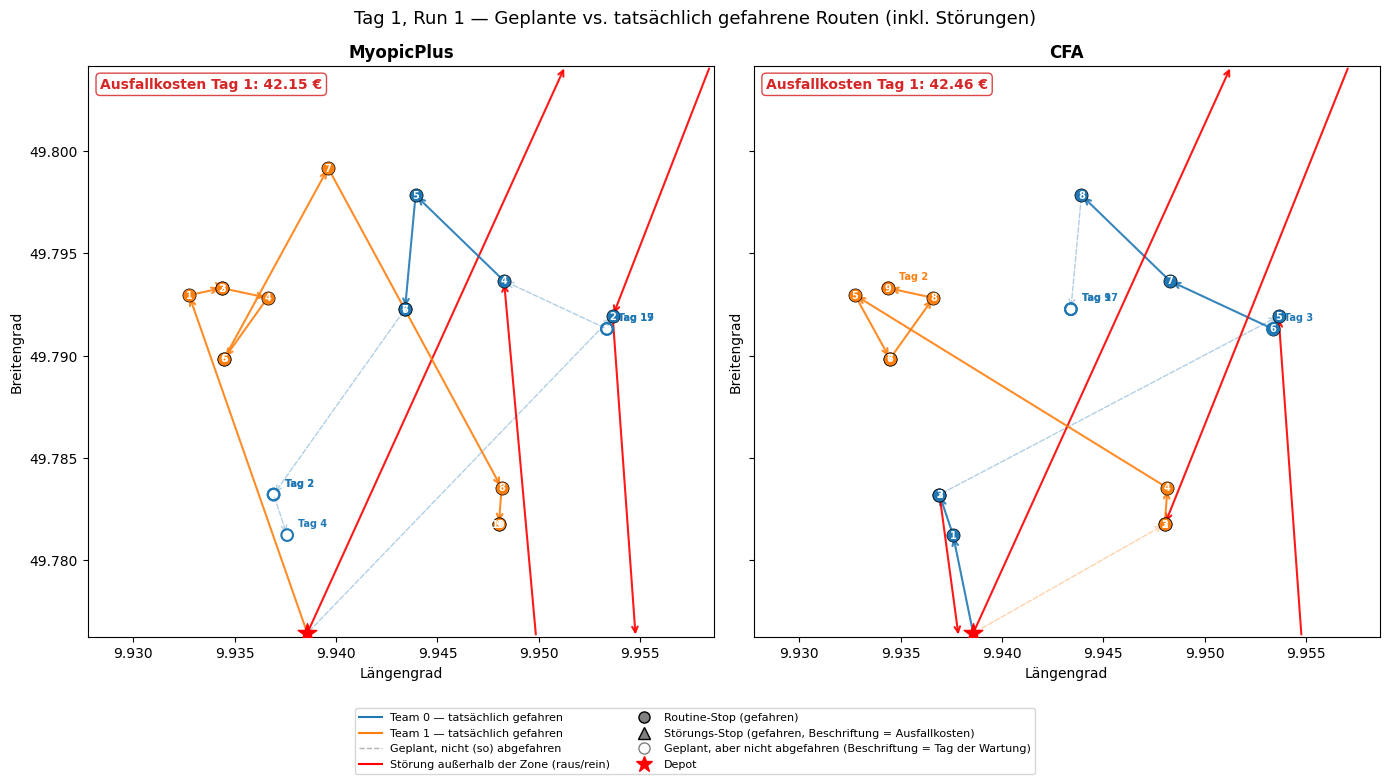

In [7]:
import re

# Zoom bleibt auf der Zone (lat_min/lat_max/lon_min/lon_max aus Visualisierung 1)
BBOX = (lat_min, lat_max, lon_min, lon_max)

def clip_to_bbox(p_in, p_out, bbox):
    """Schnittpunkt der Strecke p_in→p_out mit dem Rand der Bbox.
    p_in liegt innerhalb, p_out außerhalb. Rückgabe als (lon, lat)."""
    bb_lat_min, bb_lat_max, bb_lon_min, bb_lon_max = bbox
    x0, y0 = p_in[1], p_in[0]   # lon, lat
    x1, y1 = p_out[1], p_out[0]
    dx, dy = x1 - x0, y1 - y0

    t_candidates = []
    if dx != 0:
        for x_edge in (bb_lon_min, bb_lon_max):
            t = (x_edge - x0) / dx
            if 0 < t <= 1:
                y = y0 + t * dy
                if bb_lat_min <= y <= bb_lat_max:
                    t_candidates.append(t)
    if dy != 0:
        for y_edge in (bb_lat_min, bb_lat_max):
            t = (y_edge - y0) / dy
            if 0 < t <= 1:
                x = x0 + t * dx
                if bb_lon_min <= x <= bb_lon_max:
                    t_candidates.append(t)

    if not t_candidates:
        return None
    t = min(t_candidates)
    return (x0 + t * dx, y0 + t * dy)

def in_bbox(p, bbox):
    bb_lat_min, bb_lat_max, bb_lon_min, bb_lon_max = bbox
    return bb_lat_min <= p[0] <= bb_lat_max and bb_lon_min <= p[1] <= bb_lon_max

def draw_route_arrows(ax, route_nodes, color, bbox, linestyle='-', alpha=0.8, lw=1.5):
    """Zeichnet Routen-Pfeile innerhalb der Bbox. Segmente, die die Zone
    verlassen (Störung außerhalb), werden als roter Strich bis zum Rand
    gezeichnet (raus- bzw. reingehend)."""
    for i in range(len(route_nodes) - 1):
        a = all_coords[route_nodes[i]]
        b = all_coords[route_nodes[i + 1]]
        a_in, b_in = in_bbox(a, bbox), in_bbox(b, bbox)

        if a_in and b_in:
            ax.annotate('', xy=(b[1], b[0]), xytext=(a[1], a[0]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                        alpha=alpha, linestyle=linestyle),
                        zorder=2)
        elif a_in and not b_in:
            edge = clip_to_bbox(a, b, bbox)
            if edge:
                ax.annotate('', xy=edge, xytext=(a[1], a[0]),
                            arrowprops=dict(arrowstyle='->', color='red', lw=lw,
                                            alpha=0.9, linestyle=linestyle),
                            zorder=2)
        elif b_in and not a_in:
            edge = clip_to_bbox(b, a, bbox)
            if edge:
                ax.annotate('', xy=(b[1], b[0]), xytext=edge,
                            arrowprops=dict(arrowstyle='->', color='red', lw=lw,
                                            alpha=0.9, linestyle=linestyle),
                            zorder=2)
        # beide außerhalb: nicht gezeichnet


# ── Ausfallkosten je Störung aus den Hourly-Notes parsen ────────────────────
_NODE_RE = re.compile(r'@ (\d+) →')
_COST_RE = re.compile(r'Ausfall ([\d.]+) EUR')

def get_disruption_costs(run_json, day):
    """Gibt {node_idx: ausfallkosten_eur} für die an `day` aufgetretenen
    (und direkt eingeplanten) Störungen zurück, geparst aus den Hourly-Notes."""
    costs = {}
    pending_node = None
    for e in run_json['hourly']:
        if e['day'] != day or 'notes' not in e:
            continue
        for note in e['notes']:
            m = _NODE_RE.search(note)
            if m:
                pending_node = int(m.group(1))
            m2 = _COST_RE.search(note)
            if m2 and pending_node is not None:
                costs[pending_node] = float(m2.group(1))
                pending_node = None
    return costs


# ── Tag der tatsächlichen Wartung für nicht abgefahrene (Carryover-)Stops ───
def get_completion_day(run_json, node_idx, after_day=1):
    """Erster Tag nach `after_day`, an dem node_idx als Routine-Aufgabe
    tatsächlich abgefahren wurde (completed=True im executed_plan)."""
    for e in run_json['hourly']:
        if e['day'] <= after_day or 'executed_plan' not in e:
            continue
        for team_entry in e['executed_plan']:
            for s in team_entry['route']:
                if s['node_idx'] == node_idx and s.get('completed'):
                    return e['day']
    return None


m_disruption_costs = get_disruption_costs(myopic, 1)
c_disruption_costs = get_disruption_costs(cfa, 1)
m_total_downtime = myopic['days'][0]['downtime_cost_eur']
c_total_downtime = cfa['days'][0]['downtime_cost_eur']

print("MyopicPlus Ausfallkosten je Störung:", m_disruption_costs, "| Summe:", round(m_total_downtime, 2))
print("CFA    Ausfallkosten je Störung:", c_disruption_costs, "| Summe:", round(c_total_downtime, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

for ax, (model_name, planned_routes, executed_routes, run_json, disruption_costs, total_downtime) in zip(axes, [
    ('MyopicPlus', [mr0, mr1], [mer0, mer1], myopic, m_disruption_costs, m_total_downtime),
    ('CFA', [cr0, cr1], [cer0, cer1], cfa, c_disruption_costs, c_total_downtime),
]):
    for tid, color in enumerate(TEAM_COLORS):
        planned_nodes = [0] + [s['node_idx'] for s in planned_routes[tid]]
        executed_nodes = [0] + [s['node_idx'] for s in executed_routes[tid]]

        # Geplante Route (gestrichelt, Hintergrund) — zeigt nicht abgefahrene Strecken
        draw_route_arrows(ax, planned_nodes, color, BBOX, linestyle='--', alpha=0.35, lw=1.0)

        # Tatsächlich gefahrene Route (durchgezogen, inkl. Störungen)
        draw_route_arrows(ax, executed_nodes, color, BBOX, linestyle='-', alpha=0.85, lw=1.5)

        # Stationen (nur innerhalb der Zone)
        executed_idx = set(executed_nodes)
        for node in set(planned_nodes) | executed_idx:
            if node == 0:
                continue
            coord = all_coords[node]
            if not in_bbox(coord, BBOX):
                continue
            is_disruption = any(s['node_idx'] == node and s['task_type'] != 'routine'
                                 for s in executed_routes[tid])
            if node in executed_idx:
                marker = '^' if is_disruption else 'o'
                ax.scatter(coord[1], coord[0], s=90, color=color, marker=marker,
                           edgecolor='black', linewidth=0.5, zorder=4)
                # Ausfallkosten an Störungs-Stops anzeigen
                if is_disruption and node in disruption_costs:
                    ax.annotate(f"-{disruption_costs[node]:.0f}€", xy=(coord[1], coord[0]),
                                xytext=(8, -10), textcoords='offset points',
                                fontsize=7, color='#d62728', fontweight='bold', zorder=6)
            else:
                # geplant, aber nicht abgefahren (Carryover)
                ax.scatter(coord[1], coord[0], s=70, facecolor='none',
                           edgecolor=color, linewidth=1.5, zorder=4)
                # Tag der tatsächlichen Wartung anzeigen
                comp_day = get_completion_day(run_json, node, after_day=1)
                if comp_day is not None:
                    ax.annotate(f"Tag {comp_day}", xy=(coord[1], coord[0]),
                                xytext=(8, 6), textcoords='offset points',
                                fontsize=7, color=color, fontweight='bold', zorder=6)

        # Schritt-Nummern für tatsächliche Route (nur innerhalb der Zone)
        for step, node in enumerate(executed_nodes[1:], start=1):
            coord = all_coords[node]
            if not in_bbox(coord, BBOX):
                continue
            ax.annotate(str(step), xy=(coord[1], coord[0]),
                        fontsize=7, ha='center', va='center',
                        color='white', fontweight='bold', zorder=5)

    # Depot
    if in_bbox(depot_coord, BBOX):
        ax.scatter(depot_coord[1], depot_coord[0],
                   s=200, marker='*', color='red', zorder=4)

    # Gesamtausfallkosten Tag 1
    ax.text(0.02, 0.98, f"Ausfallkosten Tag 1: {total_downtime:.2f} €",
            transform=ax.transAxes, ha='left', va='top', fontsize=10,
            fontweight='bold', color='#d62728',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d62728', alpha=0.85))

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Längengrad')
    ax.set_ylabel('Breitengrad')

# Gemeinsame Legende
legend_elements = [
    Line2D([0], [0], color=TEAM_COLORS[0], lw=1.5, label='Team 0 — tatsächlich gefahren'),
    Line2D([0], [0], color=TEAM_COLORS[1], lw=1.5, label='Team 1 — tatsächlich gefahren'),
    Line2D([0], [0], color='gray', lw=1.0, linestyle='--', alpha=0.6, label='Geplant, nicht (so) abgefahren'),
    Line2D([0], [0], color='red', lw=1.5, label='Störung außerhalb der Zone (raus/rein)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black',
           markersize=8, label='Routine-Stop (gefahren)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='black',
           markersize=8, label='Störungs-Stop (gefahren, Beschriftung = Ausfallkosten)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='gray',
           markersize=8, label='Geplant, aber nicht abgefahren (Beschriftung = Tag der Wartung)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markeredgecolor='red',
           markersize=12, label='Depot'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=8, bbox_to_anchor=(0.5, -0.12))

fig.suptitle('Tag 1, Run 1 — Geplante vs. tatsächlich gefahrene Routen (inkl. Störungen)', fontsize=13)
plt.tight_layout()
plt.show()


## Visualisierung 2 — Routen-Reihenfolge (Gantt-Diagramm Tag 1)

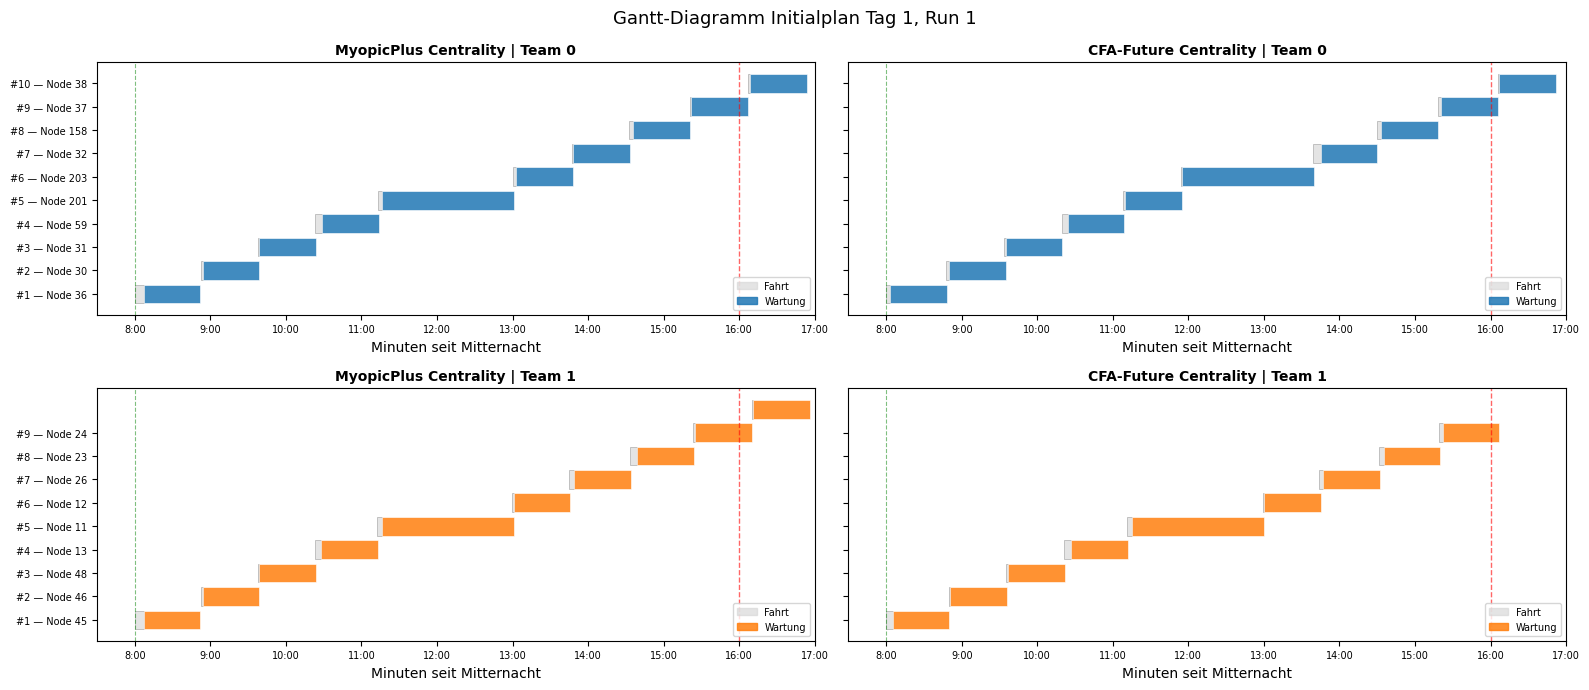

In [8]:
def parse_hhmm(s):
    """'08:03' → Minuten seit Mitternacht."""
    h, m = s.split(':')
    return int(h) * 60 + int(m)

def build_gantt_df(route_t0, route_t1, label):
    rows = []
    for tid, route in enumerate([route_t0, route_t1]):
        for step, s in enumerate(route, start=1):
            arr = parse_hhmm(s['arrival'])
            dep = parse_hhmm(s['departure'])
            rows.append({
                'model': label,
                'team': tid,
                'step': step,
                'node': s['node_idx'],
                'start': arr,
                'end': dep,
                'service': dep - arr,
                'travel_min': s['travel_min'],
            })
    return pd.DataFrame(rows)

dm = build_gantt_df(mr0, mr1, 'MyopicPlus')
dc = build_gantt_df(cr0, cr1, 'CFA-Future')

fig, axes = plt.subplots(2, 2, figsize=(16, 7), sharey='row')

for col, (df_g, model_name) in enumerate([(dm, 'MyopicPlus Centrality'), (dc, 'CFA-Future Centrality')]):
    for row, tid in enumerate([0, 1]):
        ax = axes[row][col]
        team_df = df_g[df_g['team'] == tid].reset_index(drop=True)
        color = TEAM_COLORS[tid]

        yticks, yticklabels = [], []
        for i, r in team_df.iterrows():
            # Fahrt (hellgrau)
            travel_start = r['start'] - r['travel_min']
            ax.barh(i, r['travel_min'], left=travel_start,
                    color='lightgray', edgecolor='gray', linewidth=0.5, alpha=0.6)
            # Service (farbig)
            ax.barh(i, r['service'], left=r['start'],
                    color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
            yticks.append(i)
            yticklabels.append(f"#{r['step']} — Node {r['node']}")

        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=7)
        ax.set_xlabel('Minuten seit Mitternacht')
        ax.axvline(16 * 60, color='red', linestyle='--', lw=1, alpha=0.6, label='16:00 Uhr')
        ax.axvline(8 * 60, color='green', linestyle='--', lw=0.8, alpha=0.5)
        ax.set_xlim(7.5 * 60, 17 * 60)
        ax.set_xticks(range(8 * 60, 17 * 60 + 1, 60))
        ax.set_xticklabels([f"{h}:00" for h in range(8, 18)], fontsize=7)
        ax.set_title(f"{model_name} | Team {tid}", fontsize=10, fontweight='bold')

        travel_patch = mpatches.Patch(color='lightgray', alpha=0.6, label='Fahrt')
        service_patch = mpatches.Patch(color=color, alpha=0.85, label='Wartung')
        ax.legend(handles=[travel_patch, service_patch], loc='lower right', fontsize=7)

fig.suptitle('Gantt-Diagramm Initialplan Tag 1, Run 1', fontsize=13)
plt.tight_layout()
plt.show()

## Visualisierung 3 — Tag-1-Metriken im Vergleich

In [9]:
md1 = myopic['days'][0]
cd1 = cfa['days'][0]

metrics = {
    'operational_cost_eur': 'Betriebskosten (€)',
    'wage_cost_eur': 'Lohnkosten (€)',
    'fuel_cost_eur': 'Fahrtkosten (€)',
    'downtime_cost_eur': 'Ausfallkosten (€)',
    'total_cost_eur': 'Gesamtkosten (€)',
    'n_routine_tasks': 'Routineaufgaben',
    'n_routine_completed': 'Erledigt',
    'disruptions_handled': 'Störungen erledigt',
    'disruptions_carryover': 'Störungen Carryover',
}

rows = []
for key, label in metrics.items():
    rows.append({'Metrik': label, 'MyopicPlus': md1[key], 'CFA-Future': cd1[key]})
comparison_df = pd.DataFrame(rows).set_index('Metrik')
comparison_df['Δ (CFA-Future − MyopicPlus)'] = comparison_df['CFA-Future'] - comparison_df['MyopicPlus']
comparison_df['Δ%'] = (comparison_df['Δ (CFA-Future − MyopicPlus)'] / comparison_df['MyopicPlus'].replace(0, np.nan) * 100).round(1)
print(comparison_df.round(2).to_string())

                     MyopicPlus  CFA-Future  Δ (CFA-Future − MyopicPlus)   Δ%
Metrik                                                                       
Betriebskosten (€)       590.48      590.27                        -0.20 -0.0
Lohnkosten (€)           560.00      560.00                         0.00  0.0
Fahrtkosten (€)           30.48       30.27                        -0.20 -0.7
Ausfallkosten (€)         42.15       42.46                         0.31  0.7
Gesamtkosten (€)         632.63      632.73                         0.11  0.0
Routineaufgaben           20.00       20.00                         0.00  0.0
Erledigt                  14.00       15.00                         1.00  7.1
Störungen erledigt         2.00        2.00                         0.00  0.0
Störungen Carryover        0.00        0.00                         0.00  NaN


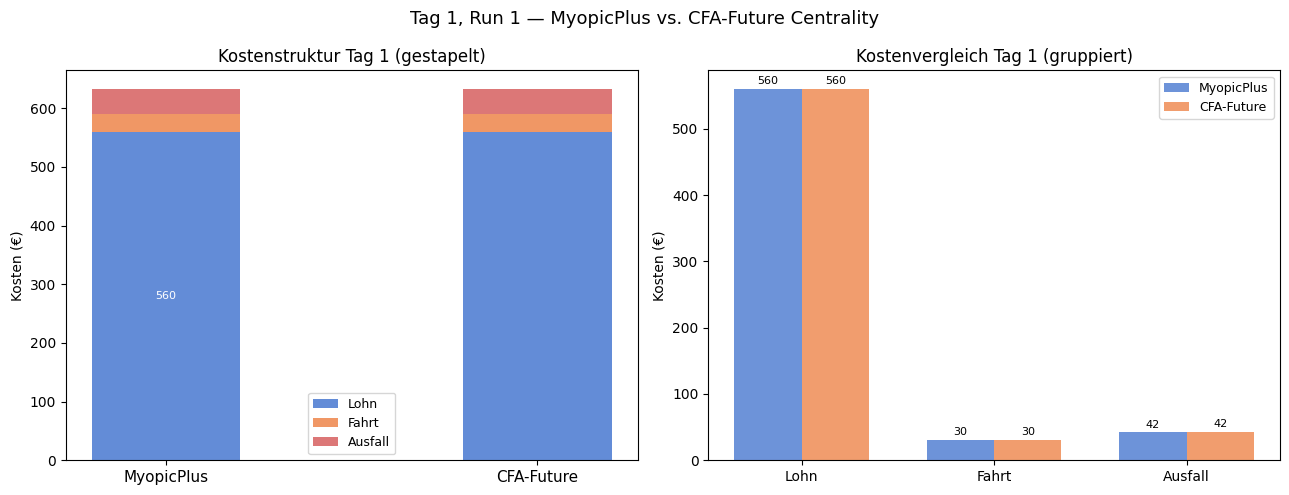


Ausfallkosten: MyopicPlus 42.1€ vs. CFA-Future 42.5€
→ CFA-Future spart -0.3€ (-1%) Ausfallkosten


In [10]:
cost_keys = ['wage_cost_eur', 'fuel_cost_eur', 'downtime_cost_eur']
cost_labels = ['Lohn', 'Fahrt', 'Ausfall']
cost_colors = ['#4878d0', '#ee854a', '#d65f5f']

myopic_vals = [md1[k] for k in cost_keys]
cfa_vals = [cd1[k] for k in cost_keys]

x = np.arange(len(cost_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gestapelter Balken
ax = axes[0]
bottom_m = bottom_c = 0
for i, (label, color, mv, cv) in enumerate(zip(cost_labels, cost_colors, myopic_vals, cfa_vals)):
    ax.bar(0, mv, bottom=bottom_m, color=color, label=label, alpha=0.85, width=0.4)
    ax.bar(1, cv, bottom=bottom_c, color=color, alpha=0.85, width=0.4)
    bottom_m += mv
    bottom_c += cv
ax.set_xticks([0, 1])
ax.set_xticklabels(['MyopicPlus', 'CFA-Future'], fontsize=11)
ax.set_ylabel('Kosten (€)')
ax.set_title('Kostenstruktur Tag 1 (gestapelt)')
ax.legend(fontsize=9)
ax.bar_label(ax.containers[0], fmt='%.0f', label_type='center', fontsize=8, color='white')

# Gruppierten Balken (Ausfallkosten separat hervorheben)
ax2 = axes[1]
bars_m = ax2.bar(x - width/2, myopic_vals, width, label='MyopicPlus', color='#4878d0', alpha=0.8)
bars_c = ax2.bar(x + width/2, cfa_vals, width, label='CFA-Future', color='#ee854a', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(cost_labels)
ax2.set_ylabel('Kosten (€)')
ax2.set_title('Kostenvergleich Tag 1 (gruppiert)')
ax2.legend(fontsize=9)
ax2.bar_label(bars_m, fmt='%.0f', fontsize=8, padding=2)
ax2.bar_label(bars_c, fmt='%.0f', fontsize=8, padding=2)

fig.suptitle('Tag 1, Run 1 — MyopicPlus vs. CFA-Future Centrality', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nAusfallkosten: MyopicPlus {md1['downtime_cost_eur']:.1f}€ vs. CFA-Future {cd1['downtime_cost_eur']:.1f}€")
print(f"→ CFA-Future spart {md1['downtime_cost_eur'] - cd1['downtime_cost_eur']:.1f}€ ({(1 - cd1['downtime_cost_eur']/md1['downtime_cost_eur'])*100:.0f}%) Ausfallkosten")

## Visualisierung 4 — Routenreihenfolge: Unterschied zwischen identischen Kandidaten

In [11]:
def route_diff_table(route_m, route_c, team_id):
    """Zeigt Positions-Unterschied zwischen MyopicPlus und CFA-Future Reihenfolge."""
    m_order = [s['node_idx'] for s in route_m]
    c_order = [s['node_idx'] for s in route_c]
    
    # Position von Node X in beiden Routen
    all_nodes = sorted(set(m_order) | set(c_order))
    rows = []
    for node in all_nodes:
        m_pos = m_order.index(node) + 1 if node in m_order else None
        c_pos = c_order.index(node) + 1 if node in c_order else None
        rows.append({'Node': node, 'MyopicPlus Pos.': m_pos, 'CFA-Future Pos.': c_pos,
                     'Δ Pos.': (c_pos - m_pos) if (m_pos and c_pos) else None})
    return pd.DataFrame(rows).set_index('Node')

print("=== Team 0 ===")
print(route_diff_table(mr0, cr0, 0).to_string())
print()
print("=== Team 1 ===")
print(route_diff_table(mr1, cr1, 1).to_string())

=== Team 0 ===
      MyopicPlus Pos.  CFA-Future Pos.  Δ Pos.
Node                                          
30                  8                2      -6
31                  9                3      -6
32                  4                7       3
36                 10                1      -9
37                  6                9       3
38                  7               10       3
59                  1                4       3
158                 5                8       3
201                 2                5       3
203                 3                6       3

=== Team 1 ===
      MyopicPlus Pos.  CFA-Future Pos.  Δ Pos.
Node                                          
6                   7              NaN     NaN
11                  5              5.0     0.0
12                  6              6.0     0.0
13                  1              4.0     3.0
23                  3              8.0     5.0
24                  2              9.0     7.0
26                  4        

## Visualisierung 5 — Kostenverlauf über alle Tage (Run 1)

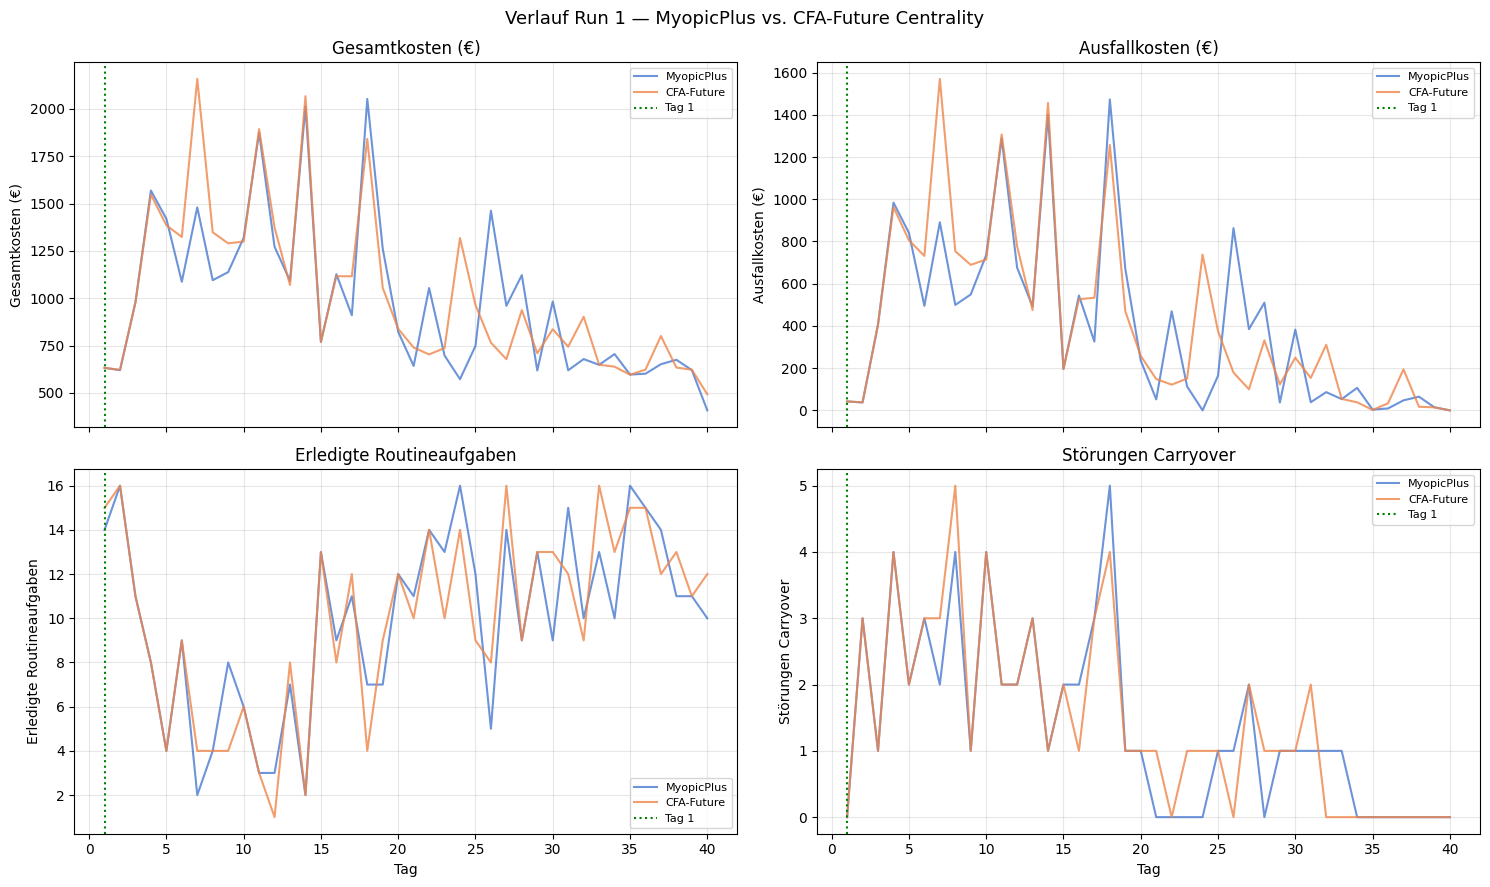

Kumulative Gesamtkosten:
  MyopicPlus:     39609.8 €
  CFA-Future: 40828.6 €


In [12]:
def days_to_df(run_json, label):
    rows = []
    for d in run_json['days']:
        rows.append({
            'day': d['day'],
            'total_cost': d['total_cost_eur'],
            'downtime_cost': d['downtime_cost_eur'],
            'operational_cost': d['operational_cost_eur'],
            'n_routine_tasks': d['n_routine_tasks'],
            'n_completed': d['n_routine_completed'],
            'carryover': d['disruptions_carryover'],
            'model': label,
        })
    return pd.DataFrame(rows)

dm_all = days_to_df(myopic, 'MyopicPlus')
dc_all = days_to_df(cfa, 'CFA-Future')

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)

plots = [
    ('total_cost', 'Gesamtkosten (€)', axes[0][0]),
    ('downtime_cost', 'Ausfallkosten (€)', axes[0][1]),
    ('n_completed', 'Erledigte Routineaufgaben', axes[1][0]),
    ('carryover', 'Störungen Carryover', axes[1][1]),
]

for col, label, ax in plots:
    ax.plot(dm_all['day'], dm_all[col], label='MyopicPlus', color='#4878d0', alpha=0.8, lw=1.5)
    ax.plot(dc_all['day'], dc_all[col], label='CFA-Future', color='#ee854a', alpha=0.8, lw=1.5)
    ax.axvline(1, color='green', linestyle=':', lw=1.5, label='Tag 1')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel('Tag')

fig.suptitle('Verlauf Run 1 — MyopicPlus vs. CFA-Future Centrality', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Kumulative Gesamtkosten:")
print(f"  MyopicPlus:     {dm_all['total_cost'].sum():.1f} €")
print(f"  CFA-Future: {dc_all['total_cost'].sum():.1f} €")